## 1. Data collection

MovieLens Latest Small was selected because it contains movie metadata, genres, user ratings, and tags. It is suitable for both content-based recommendations and an optional collaborative/quality signal.

The included dataset is for development and education. See `data/raw/README.txt` for source and license information.

# Capstone 8 - Movie Recommendation System

**Program:** Machine Learning Models  
**Project:** Content-based movie recommender with an optional rating-quality blend

This notebook follows every required project phase: data collection, loading, exploration, feature creation, cosine similarity, Top-N ranking, explanations, results presentation, and reflection.

**Dataset:** [MovieLens Latest Small](https://grouplens.org/datasets/movielens/latest/) from GroupLens Research. The dataset files are stored in `../data/raw/`.

In [1]:
# Import the libraries used in the project
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Make paths work when the notebook is run from either the project root or notebooks folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
for folder in [PROCESSED_DIR, OUTPUT_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT.resolve())

Project root: C:\Users\user\Capstone Project\Capstone project_! final


## 2. Data loading and verification

In [2]:
# Load the MovieLens CSV files
movies = pd.read_csv(DATA_DIR / 'movies.csv')
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
tags = pd.read_csv(DATA_DIR / 'tags.csv')

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)
print('Tags shape:', tags.shape)
display(movies.head())
display(ratings.head())
display(tags.head())

Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [3]:
# Check data types, missing values, and duplicate records
quality_summary = pd.DataFrame({
    'dataset': ['movies', 'ratings', 'tags'],
    'rows': [len(movies), len(ratings), len(tags)],
    'columns': [movies.shape[1], ratings.shape[1], tags.shape[1]],
    'missing_values': [movies.isna().sum().sum(), ratings.isna().sum().sum(), tags.isna().sum().sum()],
    'duplicate_rows': [movies.duplicated().sum(), ratings.duplicated().sum(), tags.duplicated().sum()]
})
display(quality_summary)

# Drop only exact duplicates; keep tag rows with missing tag text out of feature construction
movies = movies.drop_duplicates().copy()
ratings = ratings.drop_duplicates().copy()
tags = tags.drop_duplicates().copy()
tags['tag'] = tags['tag'].fillna('')

,dataset,rows,columns,missing_values,duplicate_rows
0,movies,9742,3,0,0
1,ratings,100836,4,0,0
2,tags,3683,4,0,0


## 3. Exploratory data analysis

In [4]:
# Core dataset statistics
n_users = ratings['userId'].nunique()
n_rated_movies = ratings['movieId'].nunique()
n_movies = movies['movieId'].nunique()
n_ratings = len(ratings)
possible_ratings = n_users * n_rated_movies
sparsity = (1 - n_ratings / possible_ratings) * 100

eda_summary = pd.DataFrame({
    'Metric': ['Unique users', 'Movies in metadata', 'Rated movies', 'Total ratings', 'Mean rating', 'Rating matrix sparsity (%)'],
    'Value': [n_users, n_movies, n_rated_movies, n_ratings, round(ratings['rating'].mean(), 3), round(sparsity, 2)]
})
display(eda_summary)
eda_summary.to_csv(OUTPUT_DIR / 'eda_summary.csv', index=False)

,Metric,Value
0,Unique users,610.000
1,Movies in metadata,9742.000
2,Rated movies,9724.000
3,Total ratings,100836.000
4,Mean rating,3.502
5,Rating matrix sparsity (%),98.300


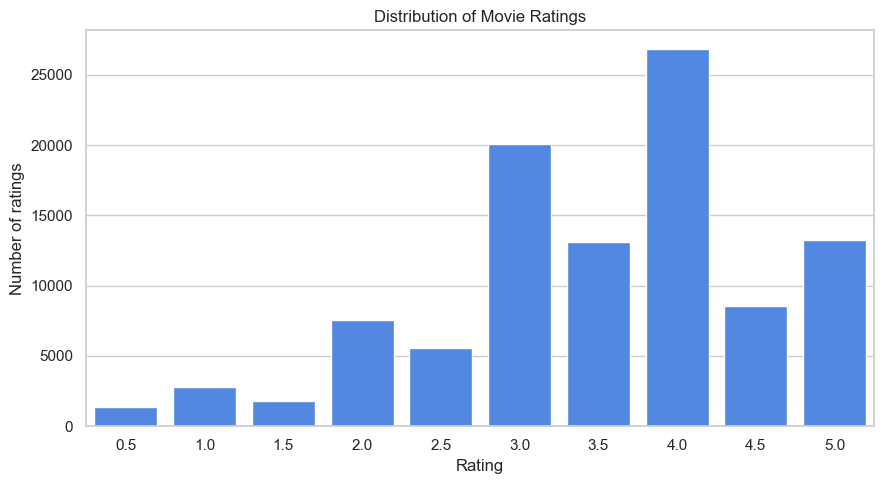

In [5]:
# Rating distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=ratings, x='rating', color='#3B82F6', ax=ax)
ax.set(title='Distribution of Movie Ratings', xlabel='Rating', ylabel='Number of ratings')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rating_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

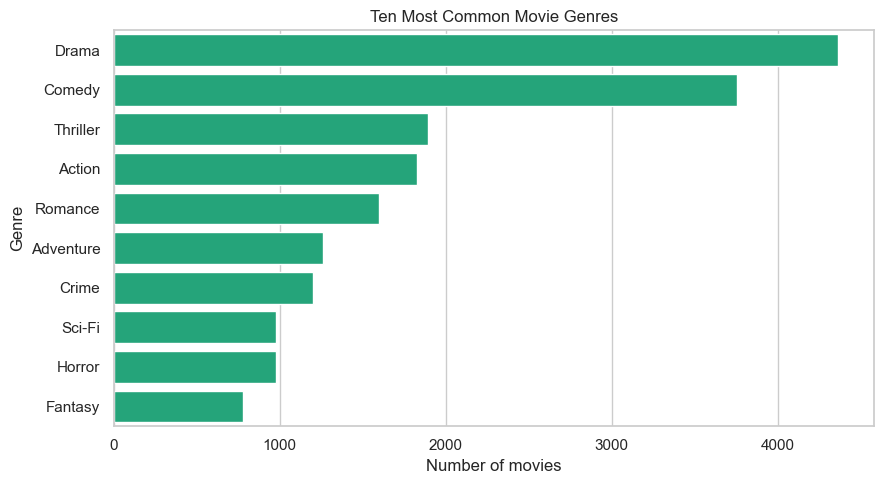

Insight: ratings are sparse because each user rates only a small part of the catalogue.
Insight: Drama and Comedy are the most common genres, so they may appear often in recommendations.


In [6]:
# Most common genres
genre_counts = (movies.assign(genre=movies['genres'].str.split('|'))
                .explode('genre')
                .query("genre != '(no genres listed)'")
                ['genre'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='#10B981', ax=ax)
ax.set(title='Ten Most Common Movie Genres', xlabel='Number of movies', ylabel='Genre')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'top_genres.png', dpi=180, bbox_inches='tight')
plt.show()

print('Insight: ratings are sparse because each user rates only a small part of the catalogue.')
print('Insight: Drama and Comedy are the most common genres, so they may appear often in recommendations.')

## 4. Feature creation

The content profile combines genres and user-supplied tags. Separators are replaced with spaces, tags are normalized, and TF-IDF gives greater weight to informative terms. Cosine similarity then compares the direction of the item vectors, rather than their raw length.

In [7]:
# Combine all tags belonging to each movie
tag_text = (tags.assign(tag=tags['tag'].str.lower().str.replace(r'[^a-z0-9 ]', ' ', regex=True))
            .groupby('movieId')['tag']
            .apply(lambda values: ' '.join(values))
            .reset_index(name='tag_text'))

# Add rating statistics for the optional quality blend
rating_stats = (ratings.groupby('movieId')['rating']
                .agg(avg_rating='mean', rating_count='count')
                .reset_index())

movie_features = (movies.merge(tag_text, on='movieId', how='left')
                  .merge(rating_stats, on='movieId', how='left'))
movie_features['tag_text'] = movie_features['tag_text'].fillna('')
movie_features['avg_rating'] = movie_features['avg_rating'].fillna(ratings['rating'].mean())
movie_features['rating_count'] = movie_features['rating_count'].fillna(0).astype(int)
movie_features['genre_text'] = (movie_features['genres']
                                .str.replace('|', ' ', regex=False)
                                .str.replace('(no genres listed)', '', regex=False))
movie_features['content'] = (movie_features['genre_text'] + ' ' + movie_features['tag_text']).str.strip()

# Convert content into a TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(movie_features['content'])

print('Feature matrix shape:', tfidf_matrix.shape)
display(movie_features[['movieId', 'title', 'genres', 'tag_text', 'avg_rating', 'rating_count']].head())

Feature matrix shape: (9742, 1675)


,movieId,title,genres,tag_text,avg_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun,3.920930,215
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game robin williams game,3.431818,110
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old,3.259615,52
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,,2.357143,7
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,3.071429,49


## 5. Cosine similarity, ranking, and explanations

The recommender computes similarity only between the selected movie and all catalogue items, avoiding a large full similarity matrix. The optional blended score is 85% content similarity and 15% Bayesian rating quality. A minimum rating-count filter makes the quality signal more reliable.

In [8]:
# Build fast lookup structures
title_to_indices = pd.Series(movie_features.index, index=movie_features['title'].str.lower())
global_mean = ratings['rating'].mean()
prior_count = ratings.groupby('movieId').size().quantile(0.60)

def find_titles(query, limit=10):
    """Return catalogue titles containing a case-insensitive search phrase."""
    mask = movie_features['title'].str.contains(re.escape(query), case=False, na=False)
    return movie_features.loc[mask, ['movieId', 'title', 'genres']].head(limit)

def shared_features(seed_row, candidate_row):
    """Create a plain-language explanation using shared genres and tags."""
    seed_genres = set(seed_row['genres'].split('|')) - {'(no genres listed)'}
    candidate_genres = set(candidate_row['genres'].split('|')) - {'(no genres listed)'}
    common_genres = sorted(seed_genres & candidate_genres)
    seed_tags = set(seed_row['tag_text'].split())
    candidate_tags = set(candidate_row['tag_text'].split())
    common_tags = sorted(seed_tags & candidate_tags)[:4]
    parts = []
    if common_genres:
        parts.append('shared genres: ' + ', '.join(common_genres))
    if common_tags:
        parts.append('shared tags: ' + ', '.join(common_tags))
    return '; '.join(parts) if parts else 'similar metadata profile'

def recommend_movies(title, top_n=10, blend_ratings=True, min_ratings=5):
    """Recommend similar movies and explain each recommendation."""
    matches = movie_features.index[movie_features['title'].str.lower() == title.lower()].tolist()
    if not matches:
        suggestions = find_titles(title, limit=5)['title'].tolist()
        raise ValueError(f'Title not found. Possible matches: {suggestions}')
    seed_idx = matches[0]
    seed = movie_features.iloc[seed_idx]
    similarities = cosine_similarity(tfidf_matrix[seed_idx], tfidf_matrix).ravel()

    candidates = movie_features.copy()
    candidates['content_similarity'] = similarities
    candidates = candidates[candidates.index != seed_idx]
    candidates = candidates[candidates['rating_count'] >= min_ratings]

    # Bayesian rating shrinks movies with few ratings toward the global mean
    candidates['bayesian_rating'] = (
        (candidates['rating_count'] / (candidates['rating_count'] + prior_count)) * candidates['avg_rating']
        + (prior_count / (candidates['rating_count'] + prior_count)) * global_mean
    )
    candidates['rating_quality'] = (candidates['bayesian_rating'] - 0.5) / 4.5
    candidates['final_score'] = (
        0.85 * candidates['content_similarity'] + 0.15 * candidates['rating_quality']
        if blend_ratings else candidates['content_similarity']
    )

    top = candidates.sort_values(['final_score', 'rating_count'], ascending=False).head(top_n).copy()
    top['why_recommended'] = top.apply(lambda row: shared_features(seed, row), axis=1)
    result = top[['movieId', 'title', 'genres', 'content_similarity', 'avg_rating',
                  'rating_count', 'final_score', 'why_recommended']].reset_index(drop=True)
    result.index = result.index + 1
    result.index.name = 'rank'
    return result.round({'content_similarity': 3, 'avg_rating': 2, 'final_score': 3})

display(find_titles('Toy Story'))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


## 6. Generate Top-N recommendations

In [9]:
# Generate the required sample recommendations
SEED_TITLE = 'Toy Story (1995)'
TOP_N = 10
recommendations = recommend_movies(SEED_TITLE, top_n=TOP_N, blend_ratings=True)
print(f'Top {TOP_N} recommendations similar to {SEED_TITLE}:')
display(recommendations)

# Save results for reporting
recommendations.to_csv(OUTPUT_DIR / 'recommendations_toy_story.csv')
movie_features.to_csv(PROCESSED_DIR / 'movie_features.csv', index=False)
print('Results saved to outputs/recommendations_toy_story.csv')

Top 10 recommendations similar to Toy Story (1995):


,movieId,title,genres,content_similarity,avg_rating,rating_count,final_score,why_recommended
rank,,,,,,,,
1,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862,3.52,92,0.833,"shared genres: Adventure, Animation, Children,..."
2,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644,3.86,97,0.659,"shared genres: Adventure, Animation, Children,..."
3,122918,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.368,3.93,27,0.425,shared genres: Adventure; shared tags: fun
4,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.87,132,0.416,"shared genres: Adventure, Animation, Children,..."
5,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.72,37,0.411,"shared genres: Adventure, Animation, Children,..."
6,65261,Ponyo (Gake no ue no Ponyo) (2008),Adventure|Animation|Children|Fantasy,0.345,4.00,11,0.405,"shared genres: Adventure, Animation, Children,..."
7,134853,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,0.347,3.81,43,0.405,"shared genres: Adventure, Animation, Children,..."
8,162578,Kubo and the Two Strings (2016),Adventure|Animation|Children|Fantasy,0.345,4.00,6,0.403,"shared genres: Adventure, Animation, Children,..."
9,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.45,10,0.403,"shared genres: Adventure, Animation, Children,..."


Results saved to outputs/recommendations_toy_story.csv


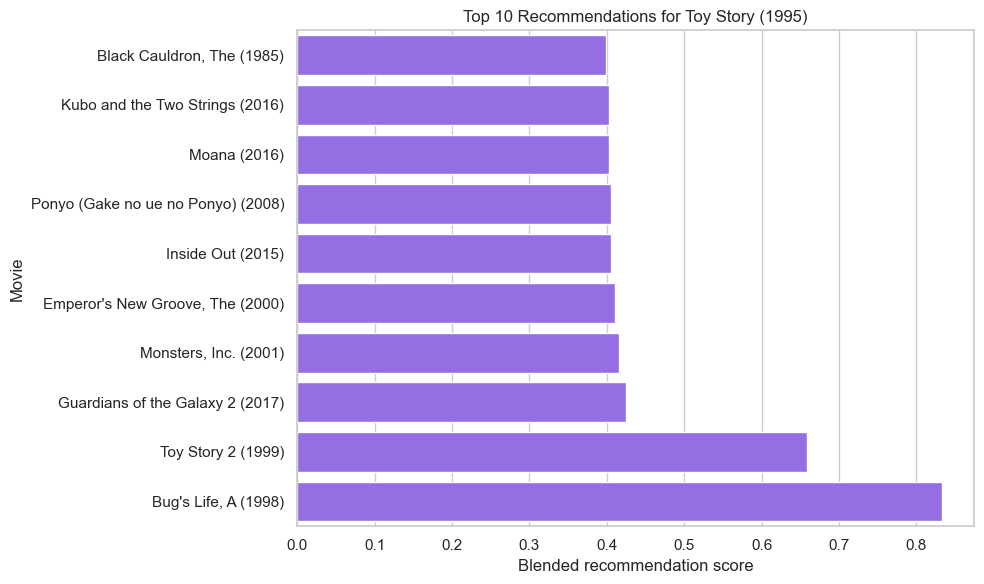

In [10]:
# Visual presentation of recommendation scores
plot_data = recommendations.sort_values('final_score')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, x='final_score', y='title', color='#8B5CF6', ax=ax)
ax.set(title=f'Top {TOP_N} Recommendations for {SEED_TITLE}', xlabel='Blended recommendation score', ylabel='Movie')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'recommendation_scores.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Results and interpretation

- Recommended movies are ranked mainly by TF-IDF cosine similarity of genres and tags.
- Each result includes shared genres/tags so the recommendation is understandable.
- The small rating-quality component rewards well-reviewed movies without replacing content relevance.
- The minimum-rating rule reduces the risk that a movie with only one unusually high rating dominates the ranking.

The system is useful for finding items similar to a movie a user already likes. However, genre/tag metadata can be incomplete, popularity bias can remain, and the model does not fully learn an individual user's taste.

## 8. Reflection and possible improvements

This project showed how raw user-item data can be transformed into explainable recommendations. TF-IDF and cosine similarity provide a simple, reproducible content-based baseline. The optional Bayesian rating blend adds a light collaborative signal.

Future improvements could include a user-profile recommender based on several liked movies, matrix factorization, time-aware ratings, richer plot/actor metadata, offline Precision@K evaluation, and a Streamlit dashboard.

## Reuse the recommender

Change the title below to any exact title returned by `find_titles()`:

```python
find_titles('matrix')
recommend_movies('Matrix, The (1999)', top_n=5)
```